<a href="https://colab.research.google.com/github/SM-2402/Cognitive-Computing-UCS420-Lab-Assignments/blob/main/CC_Lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Cognitive Computing Lab Assignment 4

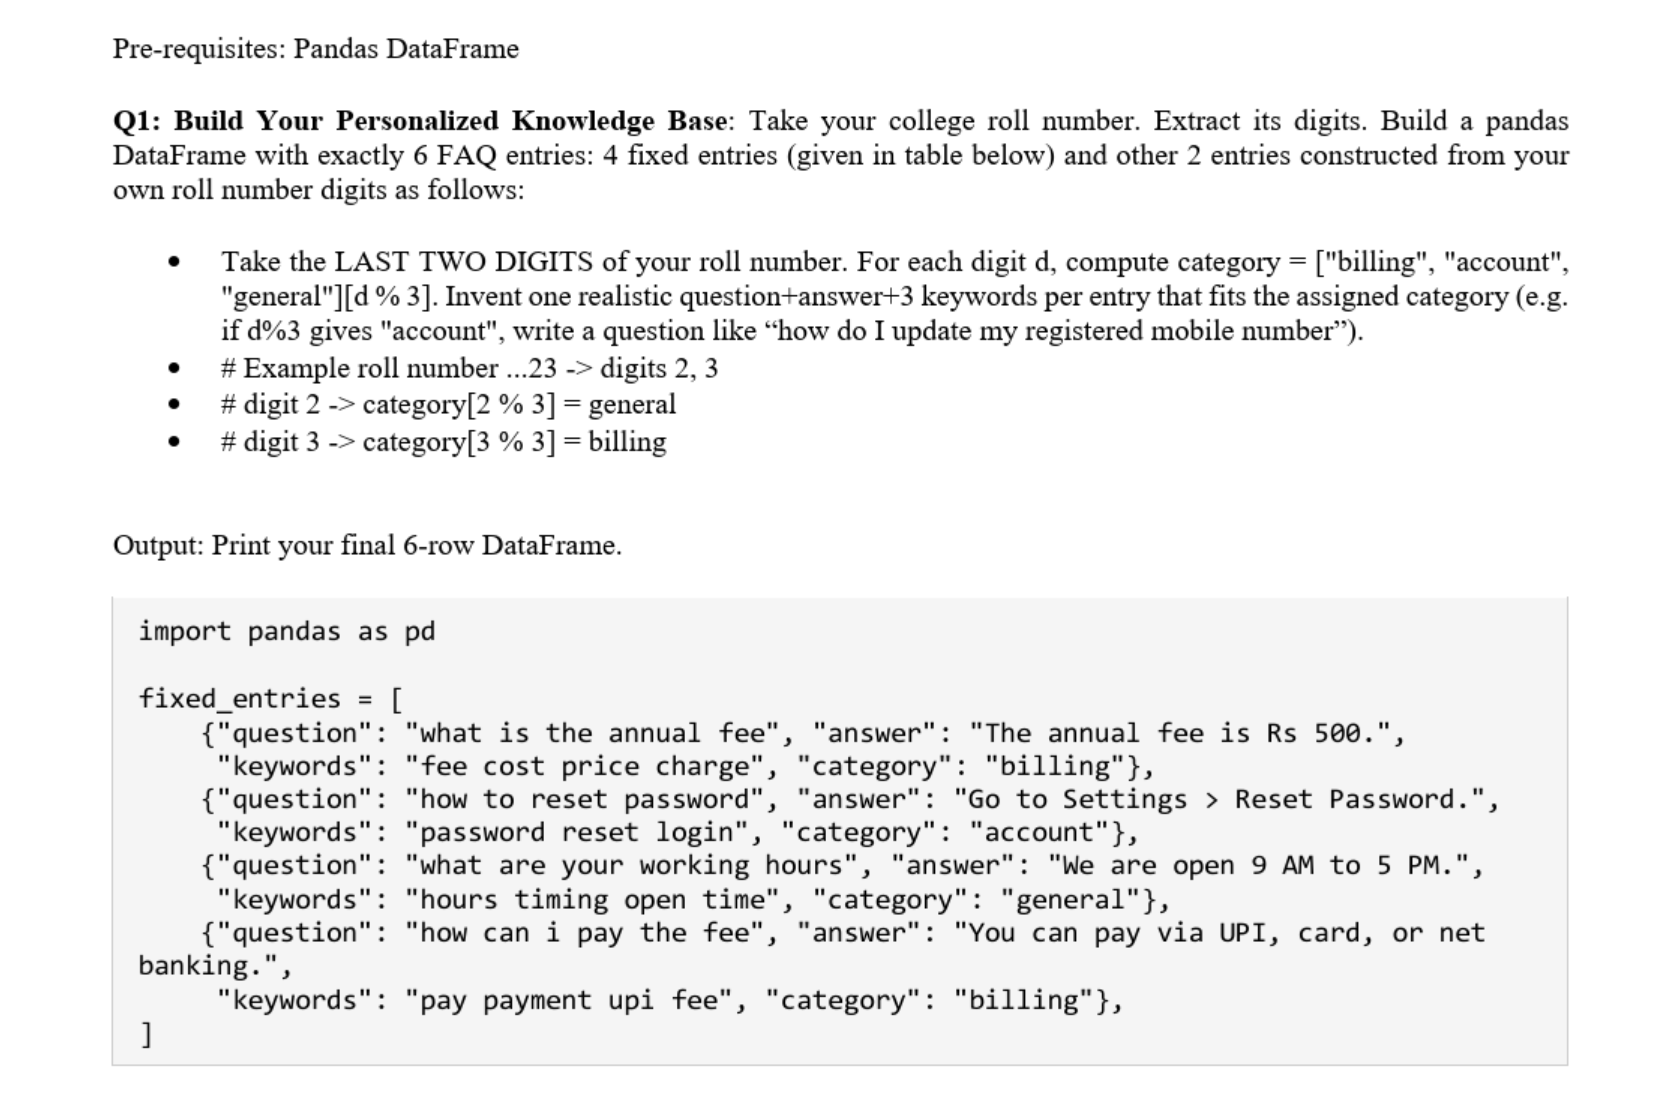

In [ ]:
import pandas as pd

In [ ]:
roll_no = 1024170033

fixed_entries = [
    {
        "question": "what is the annual fee",
        "answer": "The annual fee is Rs 500.",
        "keywords": "fee cost price charge",
        "category": "billing"
    },
    {
        "question": "how to reset password",
        "answer": "Go to Settings > Reset Password.",
        "keywords": "password reset login",
        "category": "account"
    },
    {
        "question": "what are your working hours",
        "answer": "We are open 9 AM to 5 PM.",
        "keywords": "hours timing open time",
        "category": "general"
    },
    {
        "question": "how can i pay the fee",
        "answer": "You can pay via UPI, card, or net banking.",
        "keywords": "pay payment upi fee",
        "category": "billing"
    }
]

digits = [3, 3]

categories = ["billing", "account", "general"]

for digit in digits:
    category = categories[digit % 3]

    if category == "billing":
        question = "how can i check my fee payment status"
        answer = "You can check your fee payment status from the billing section."
        keywords = "fee payment status billing"

    fixed_entries.append({
        "question": question,
        "answer": answer,
        "keywords": keywords,
        "category": category
    })

In [ ]:
df = pd.DataFrame(fixed_entries)

In [ ]:
df

,question,answer,keywords,category
0,what is the annual fee,The annual fee is Rs 500.,fee cost price charge,billing
1,how to reset password,Go to Settings > Reset Password.,password reset login,account
2,what are your working hours,We are open 9 AM to 5 PM.,hours timing open time,general
3,how can i pay the fee,"You can pay via UPI, card, or net banking.",pay payment upi fee,billing
4,how can i check my fee payment status,You can check your fee payment status from the...,fee payment status billing,billing
5,how can i check my fee payment status,You can check your fee payment status from the...,fee payment status billing,billing


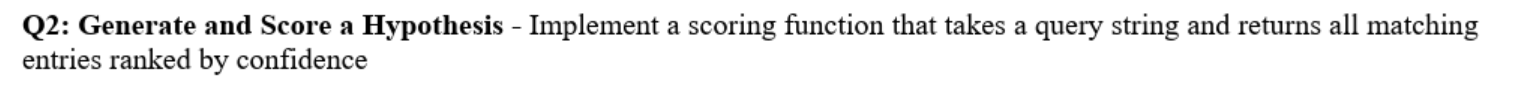

In [ ]:
def search_faq(query):
    query_words = set(query.lower().split())
    results = []

    for i, row in df.iterrows():
        text = (row["question"] + " " + row["keywords"]).lower()
        text_words = set(text.split())

        matches = query_words.intersection(text_words)

        if len(matches) > 0:
            confidence = len(matches) / len(query_words)

            results.append({
                "question": row["question"],
                "answer": row["answer"],
                "category": row["category"],
                "confidence": round(confidence, 2)
            })

    results.sort(key=lambda x: x["confidence"], reverse=True)

    return pd.DataFrame(results)

In [ ]:
query = input("Enter your question: ")

result = search_faq(query)

if len(result) > 0:
    print("Matching FAQs:")
    print(result)
else:
    print("No matching FAQ found.")

Enter your question: how can i pay fee
Matching FAQs:
                                question  \
0                  how can i pay the fee   
1  how can i check my fee payment status   
2  how can i check my fee payment status   
3                 what is the annual fee   
4                  how to reset password   

                                              answer category  confidence  
0         You can pay via UPI, card, or net banking.  billing         1.0  
1  You can check your fee payment status from the...  billing         0.8  
2  You can check your fee payment status from the...  billing         0.8  
3                          The annual fee is Rs 500.  billing         0.2  
4                   Go to Settings > Reset Password.  account         0.2  


In [ ]:
result = search_faq("how can I pay my fee")
result

,question,answer,category,confidence
0,how can i pay the fee,"You can pay via UPI, card, or net banking.",billing,0.83
1,how can i check my fee payment status,You can check your fee payment status from the...,billing,0.83
2,how can i check my fee payment status,You can check your fee payment status from the...,billing,0.83
3,what is the annual fee,The annual fee is Rs 500.,billing,0.17
4,how to reset password,Go to Settings > Reset Password.,account,0.17


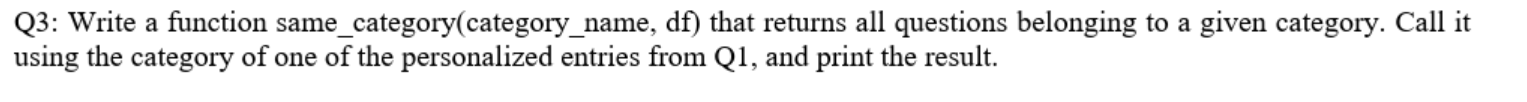

In [ ]:
def same_category(category_name, df):
    result = df[df["category"] == category_name]
    return result["question"]

In [ ]:
result = same_category("billing", df)
result

,question
0,what is the annual fee
3,how can i pay the fee
4,how can i check my fee payment status
5,how can i check my fee payment status


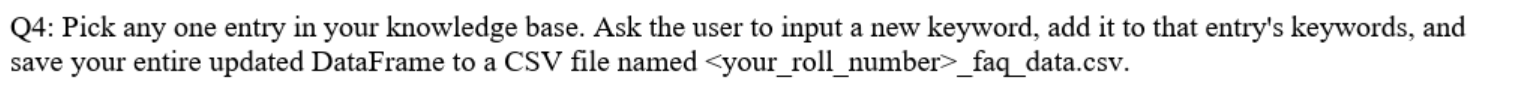

In [ ]:
index = 0
new_keyword = input("Enter a new keyword: ")
df.loc[index, "keywords"] = df.loc[index, "keywords"] + " " + new_keyword

print("Updated entry:")
print(df.loc[index])

Enter a new keyword: discount
Updated entry:
question            what is the annual fee
answer           The annual fee is Rs 500.
keywords    fee cost price charge discount
category                           billing
Name: 0, dtype: object


In [ ]:
df.to_csv("1024170033_faq_data.csv",index=False)

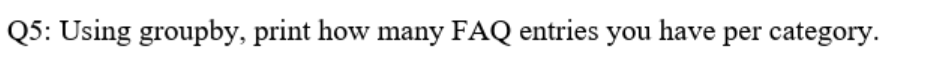

In [ ]:
category_count = df.groupby("category").size()
category_count

,0
category,
account,1
billing,4
general,1


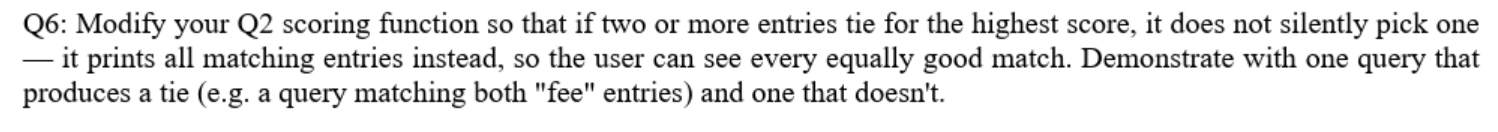

In [ ]:
def search_faq(query):
    query_words = set(query.lower().split())
    results = []

    for i, row in df.iterrows():
        text = (row["question"] + " " + row["keywords"]).lower()
        text_words = set(text.split())

        matches = query_words.intersection(text_words)

        if len(matches) > 0:
            confidence = len(matches) / len(query_words)

            results.append({
                "question": row["question"],
                "answer": row["answer"],
                "category": row["category"],
                "confidence": round(confidence, 2)
            })

    if len(results) == 0:
        return pd.DataFrame()

    highest_score = max(result["confidence"] for result in results)

    best_results = [
        result for result in results
        if result["confidence"] == highest_score
    ]

    return pd.DataFrame(best_results)

In [ ]:
query = input("Enter your question: ")

result = search_faq(query)

if len(result) > 0:
    print("Best matching entries:")
    print(result)
else:
    print("No matching FAQ found.")

Enter your question: fee
Best matching entries:
                                question  \
0                 what is the annual fee   
1                  how can i pay the fee   
2  how can i check my fee payment status   
3  how can i check my fee payment status   

                                              answer category  confidence  
0                          The annual fee is Rs 500.  billing         1.0  
1         You can pay via UPI, card, or net banking.  billing         1.0  
2  You can check your fee payment status from the...  billing         1.0  
3  You can check your fee payment status from the...  billing         1.0  
